<a href="https://colab.research.google.com/github/yxmauw/eye-disease-classification/blob/main/EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setting up local directory to work
Stream data direct from kaggle using Kaggle API

In [ ]:
# install kaggle API if never done before for your google account
# !pip install kaggle

In [ ]:
!git clone https://github.com/yxmauw/eye-disease-classification.git

Cloning into 'eye-disease-classification'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 190 (delta 32), reused 0 (delta 0), pack-reused 134
Receiving objects: 100% (190/190), 21.17 MiB | 18.92 MiB/s, done.
Resolving deltas: 100% (109/109), done.


In [ ]:
!mkdir ~/.kaggle #Make a directory named “.kaggle”

In [ ]:
!cp ./eye-disease-classification/kaggle.json ~/.kaggle/ # Copy the “kaggle.json” into this new directory

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json # Allocate the required permission for this file

In [ ]:
!kaggle datasets download gunavenkatdoddi/eye-diseases-classification # download dataset

 99% 725M/736M [00:07<00:00, 141MB/s]
100% 736M/736M [00:07<00:00, 104MB/s]


In [ ]:
!unzip eye-diseases-classification.zip

## Explore images

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
%config InlineBackend.figure_format = 'retina'

### Number of images in dataset:

In [ ]:
import fnmatch
import os

# image files count
cataract_count = len(fnmatch.filter(os.listdir('./dataset/cataract'), '*.jpg'))
dre_count = len(fnmatch.filter(os.listdir('./dataset/diabetic_retinopathy'), '*.jpeg'))
glaucoma_count = len(fnmatch.filter(os.listdir('./dataset/glaucoma'), '*.jpg'))
normal_count = len(fnmatch.filter(os.listdir('./dataset/normal'), '*.jpg'))
total_image_count = cataract_count + dre_count + \
                    glaucoma_count + normal_count
# print count
print('---Categories---')
print('Cataract:', cataract_count)
print('Diabetic retinopathy:', dre_count)
print('Glaucoma:', glaucoma_count)
print('Normal', normal_count)
print()
print('---Total image count---')
print(total_image_count)

---Categories---
Cataract: 938
Diabetic retinopathy: 1098
Glaucoma: 906
Normal 1074

---Total image count---
4016


### Image dimensions, properties:

In [ ]:
# load example image
from PIL import Image 
im = Image.open('./dataset/glaucoma/1495_left.jpg')
# summarize some details about the image
print(im.format)
print(im.mode)
print(im.size) # size already 512 x 512

pixels = np.asarray(im)
print(pixels[0])
print(pixels.shape) # 3 channel last

JPEG
RGB
(512, 512)
[[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [0 0 0]
 [0 0 0]
 [0 0 0]]
(512, 512, 3)


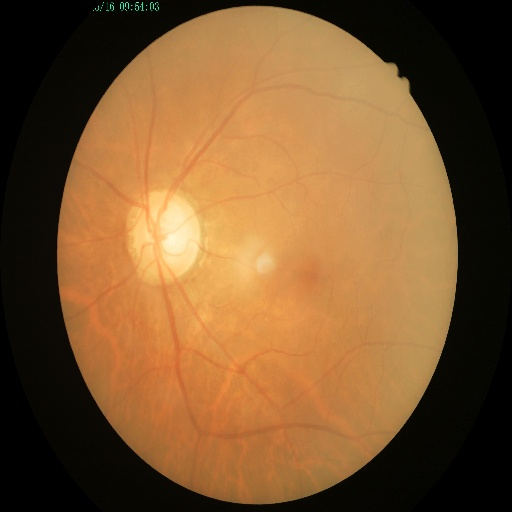

In [ ]:
#Import library
from IPython import display
display.Image(filename='./dataset/glaucoma/1495_left.jpg', width=200, height=150)

In [ ]:
# calculate image pixel mean, min, max

mean = pixels.mean()
print('Mean: %.3f' % mean)
# confirm pixel range is 0-255
print('Min: %.3f, Max: %.3f' % (pixels.min(), pixels.max()))

Mean: 86.173
Min: 0.000, Max: 255.000


## Visualise preprocessed images

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
print(tf.__version__) #2.8.2

2.8.2


What happens after resizing and rescaling: 

In [ ]:
resize_and_rescale = tf.keras.Sequential([   
    layers.Resizing(160,160) ,  # needs to be symmetrical
    layers.Rescaling(1./255) # desired height, width in model pipeline
])

result = resize_and_rescale(pixels)
print(result.shape) # new shape, channels

(160, 160, 3)


What happens to image pixel values after rescaling:

In [ ]:
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


Show images before and after preprocessing:

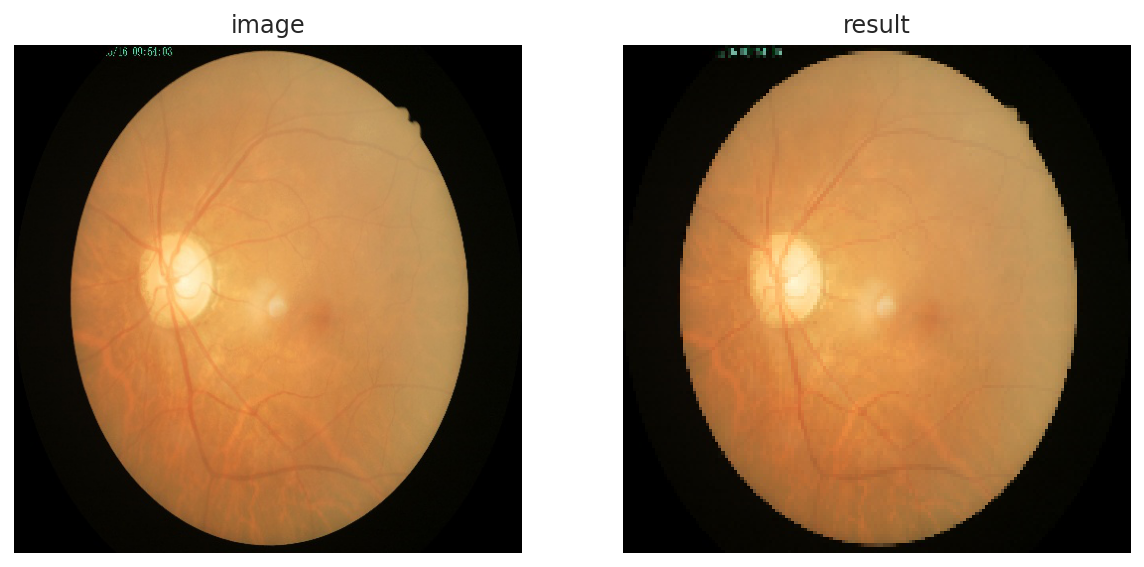

In [ ]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,8))
ax0.imshow(im)
ax0.axis('off')
ax0.set_title('image')
# after pixel normalisation
ax1.imshow(result)
ax1.axis('off')
ax1.set_title('result')
plt.show() # result seems to have slight blurring of image, but still good definition

## Create train, validation and test datasets

In [180]:
!pip install split-folders

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [186]:
# first allocate a test set using this library
import splitfolders

splitfolders.ratio('./dataset/', output="./work_directory/", seed=1, ratio=(.8,.1,.1))

Copying files: 4217 files [00:01, 2210.68 files/s]


In [188]:
# generate dataset that can be used for machine learning
from tensorflow.keras.utils import image_dataset_from_directory

image_size = (160, 160) # very important to get this right, will determine model success
batch_size = 32

train_ds = image_dataset_from_directory(
    './work_directory/train',
    image_size=image_size,
    shuffle=True,
    seed=1,
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    './work_directory/val',
    image_size=image_size,
    shuffle=True,
    seed=1,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = image_dataset_from_directory( # for model evaluation later
    './work_directory/test',
    image_size=image_size,
    shuffle=True,
    seed=1,
    batch_size=batch_size,
    label_mode='categorical'
)

Found 4005 files belonging to 4 classes.
Found 631 files belonging to 4 classes.
Found 426 files belonging to 4 classes.


### Visualise images and labels together

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


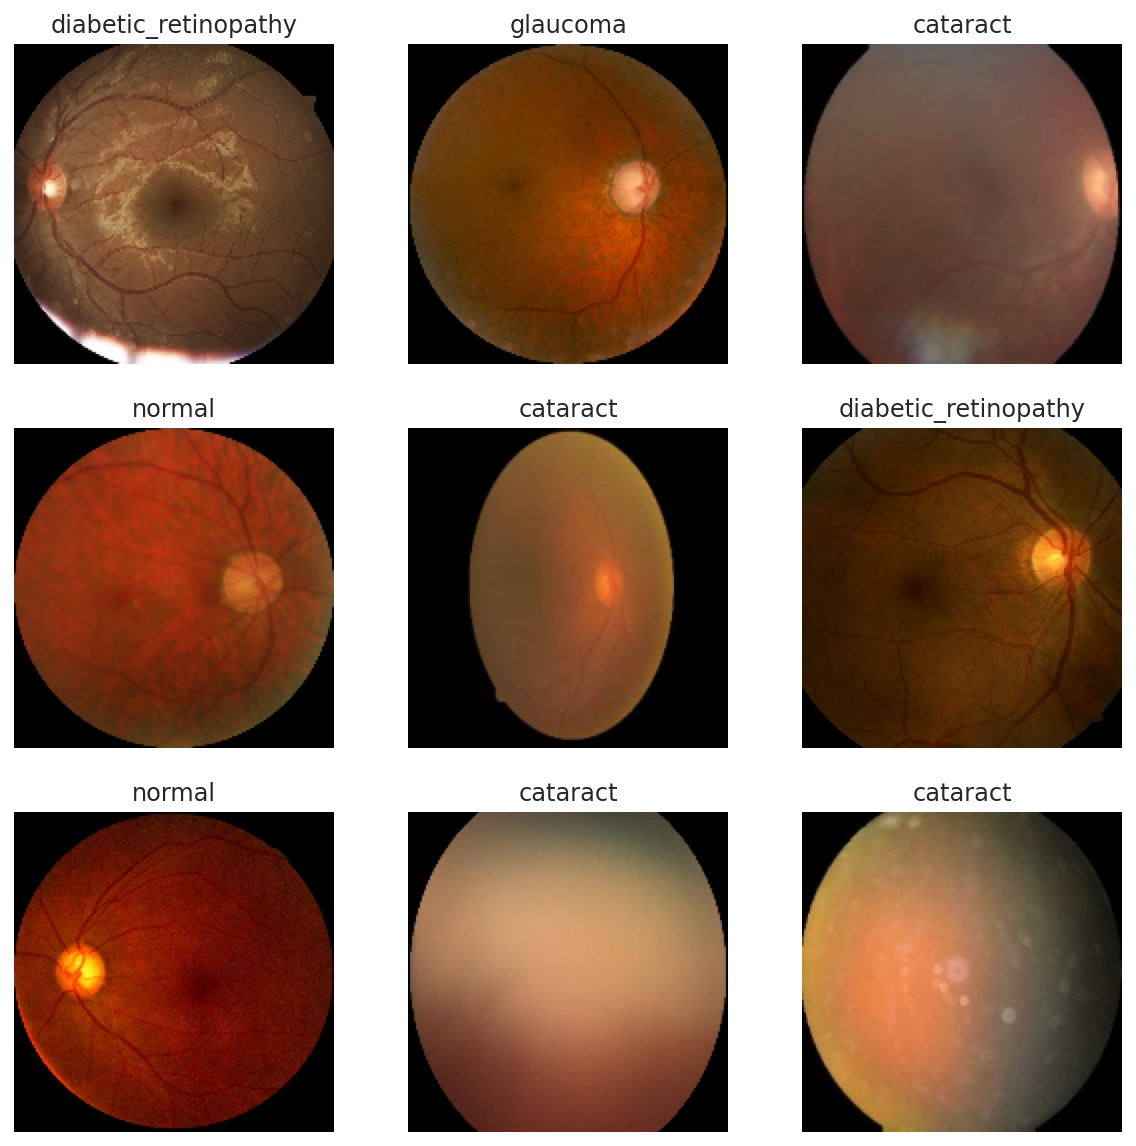

In [189]:
# preview of how images are labelled
class_names = train_ds.class_names
print(class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # each image 160 x 160
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[i], axis=0)])
    plt.axis("off")

## Configure datasets for optimal performance

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## Data augmentation

In [ ]:
data_augmentation = tf.keras.Sequential(
    [ layers.RandomFlip("horizontal_and_vertical", seed=123), 
      layers.RandomRotation(0.2, seed=123),
      layers.RandomContrast(0.2, seed=123)
    ])

### Visualise augmented images

In [ ]:
def augmented_img():
  for image, _ in train_ds.take(1):  # take a sample image from training set
    plt.figure(figsize=(8, 8))
    first_image = image[0]
    for i in range(9):
      ax = plt.subplot(3, 3, i + 1)
      augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
      plt.imshow(augmented_image[0] / 255) # rescale pixel 0 to 1
      plt.axis("off")

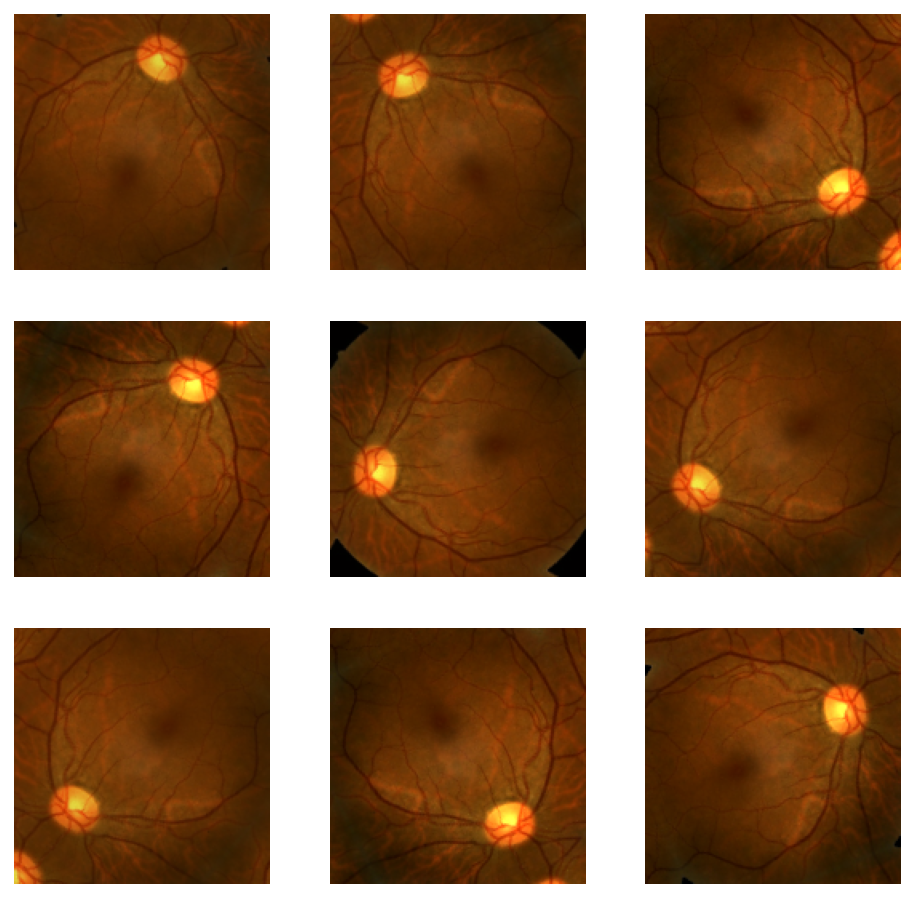

In [ ]:
augmented_img()

## Create Base EfficientNet model



In [ ]:
# Create the base model from the pre-trained model MobileNet V2
input_shape = (160, 160, 3)
base_model = tf.keras.applications.EfficientNetV2B3(input_shape=input_shape,
                                                    include_top=False,
                                                    weights='imagenet',
                                                    pooling='max')

52617216/52606240 [==============================] - 0s 0us/step


In [ ]:
base_model.trainable=True # train entire model layers, yet with pre-trained weights from ImageNet

In [ ]:
from tensorflow.keras.layers import (Dense, Activation, Dropout, Conv2D, 
                                     MaxPooling2D, BatchNormalization)
from tensorflow.keras import regularizers

In [ ]:
def E_Net():
  # add rescaling layer to base model
  inputs = tf.keras.Input(shape=(160, 160, 3))
  x = tf.keras.layers.Rescaling(1./255)(inputs) # rescaling layer
  x = base_model(x, training=True)
  x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
  x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
  x = Dropout(rate=.4, seed=123)(x)       
  output = Dense(4, activation='softmax')(x)
  # instantiate model with added layers
  model = tf.keras.Model(inputs, output)
  return model

In [ ]:
model = E_Net()

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 rescaling_3 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 batch_normalization_1 (Batc  (None, 1536)             6144      
 hNormalization)                                                 
                                                                 
 dense (Dense)               (None, 256)               393472    
                                                                 
 dropout (Dropout)           (None, 256)               0     

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
# show model in graph manner
tf.keras.utils.plot_model(model, to_file = "drive/MyDrive/Colab Notebooks/EfficientNet.png", show_shapes=True)

## Compile, fit model, run

[getting F1 score in metrics](https://aakashgoel12.medium.com/how-to-add-user-defined-function-get-f1-score-in-keras-metrics-3013f979ce0d)

In [145]:
import keras.backend as K # function to add F1 score as metric

def get_f1(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC',get_f1])

# Train the model, doing validation at the end of each epoch.
epochs = 50 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/ENet_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=5,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/ENet_history.csv')
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/50
106/106 [==============================] - 381s 3s/step - loss: 6.2211 - accuracy: 0.7371 - auc: 0.9141 - get_f1: 0.7372 - val_loss: 3.5846 - val_accuracy: 0.8697 - val_auc: 0.9789 - val_get_f1: 0.8617
Epoch 2/50
106/106 [==============================] - ETA: 0s - loss: 2.7458 - accuracy: 0.8376 - auc: 0.9603 - get_f1: 0.8348

106/106 [==============================] - 368s 3s/step - loss: 2.7458 - accuracy: 0.8376 - auc: 0.9603 - get_f1: 0.8348 - val_loss: 1.7264 - val_accuracy: 0.8975 - val_auc: 0.9834 - val_get_f1: 0.8720
Epoch 3/50
106/106 [==============================] - 359s 3s/step - loss: 1.2675 - accuracy: 0.8764 - auc: 0.9771 - get_f1: 0.8735 - val_loss: 0.8572 - val_accuracy: 0.9004 - val_auc: 0.9851 - val_get_f1: 0.8892
Epoch 4/50
106/106 [==============================] - 397s 4s/step - loss: 0.6907 - accuracy: 0.9129 - auc: 0.9851 - get_f1: 0.9056 - val_loss: 0.6244 - val_accuracy: 0.8931 - val_auc: 0.9791 - val_get_f1: 0.8913
Epoch 5/50
106/106 [==============================] - 390s 4s/step - loss: 0.4859 - accuracy: 0.9265 - auc: 0.9898 - get_f1: 0.9226 - val_loss: 0.4646 - val_accuracy: 0.9004 - val_auc: 0.9877 - val_get_f1: 0.9057
Epoch 6/50
106/106 [==============================] - 308s 3s/step - loss: 0.4436 - accuracy: 0.9389 - auc: 0.9905 - get_f1: 0.9345 - val_loss: 0.5372 - val_ac

## Learning Curves 

In [ ]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/ENet_history.csv')
history.head(3)

,epoch,accuracy,auc,get_f1,loss,val_accuracy,val_auc,val_get_f1,val_loss
0,0,0.737107,0.914106,0.737153,6.221060,0.869693,0.978921,0.861695,3.584557
1,1,0.837582,0.960271,0.834781,2.745787,0.897511,0.983419,0.871967,1.726395
2,2,0.876408,0.977109,0.873455,1.267464,0.900439,0.985121,0.889167,0.857180


In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

In [ ]:
def learning_curves(acc,val_acc,loss,val_loss):
  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(acc, label='Training Accuracy')
  plt.plot(val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.ylabel('Accuracy')
  plt.ylim([min(plt.ylim()),max(plt.ylim())])
  plt.xlim([0,max(plt.xlim())])
  plt.title('Training and Validation Accuracy')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Training Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.ylabel('Cross Entropy')
  plt.ylim([min(plt.ylim()),max(plt.ylim())])
  plt.xlim([0,max(plt.xlim())])
  plt.title('Training and Validation Loss')
  plt.xlabel('epoch')
  plt.show()
  return plt.show()

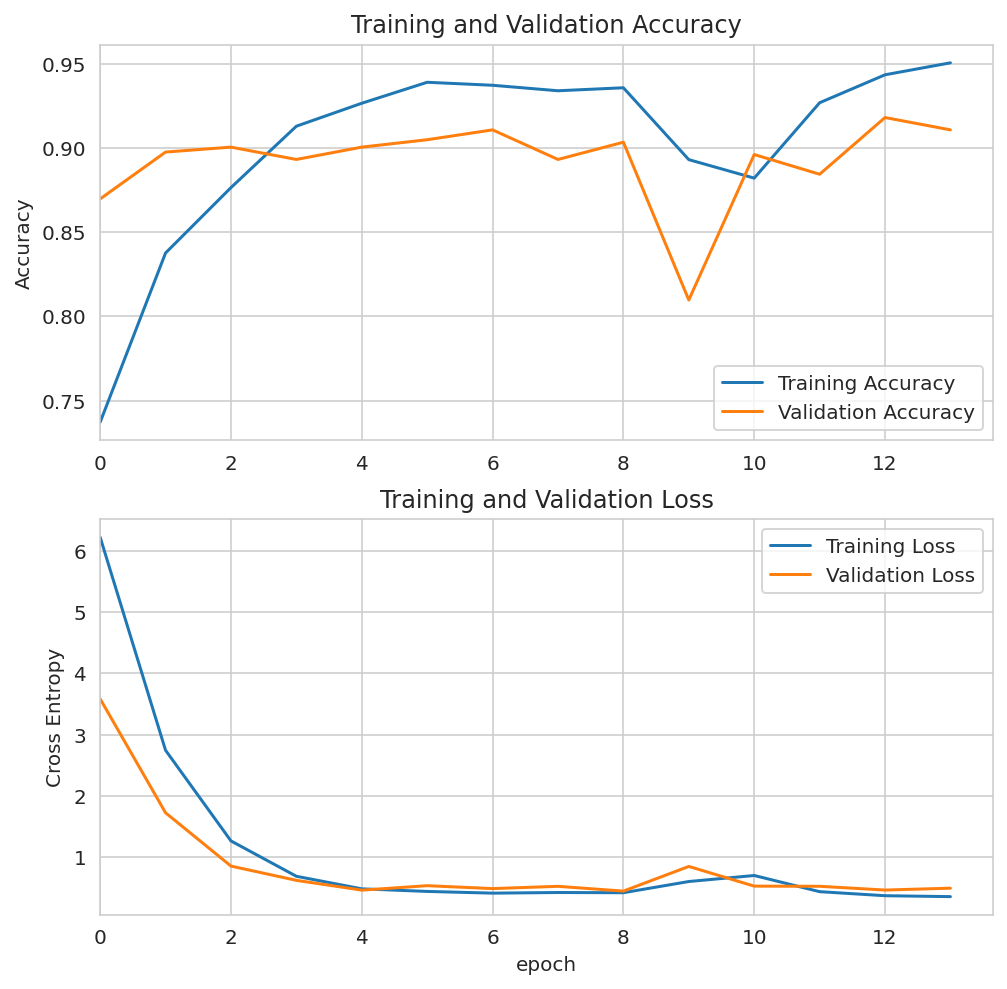

In [ ]:
learning_curves(acc,val_acc,loss,val_loss)

In [ ]:
# check for generalisation for epoch 9
def metrics(epoch_num):
  val_auc = history.loc[history['epoch']==epoch_num, ['val_auc']].values[0][0]
  auc = history.loc[history['epoch']==epoch_num, ['auc']].values[0][0]
  auc_diff = (auc - val_auc)*100 / auc
  print('AUC percentage difference is:', abs(auc_diff), '%')

  val_acc = history.loc[history['epoch']==epoch_num, ['val_accuracy']].values[0][0]
  acc = history.loc[history['epoch']==epoch_num, ['accuracy']].values[0][0]
  acc_diff = (acc - val_acc)*100 / acc
  print()
  print('Accuracy percentage difference is:', abs(acc_diff), '%')

In [ ]:
metrics(epoch_num=8) # 8 because record epoch 9 as 8

AUC percentage difference is: 1.3836777442149075 %

Accuracy percentage difference is: 3.6931908422130224 %


Best base EfficientNet model found with the following validation metrics:

| Name     |   Scores   |
|:---------|:----------:|
|Accuracy  |0.9033675194|
|AUC       |0.986328721 |
|F1 score  |0.8989197016|
|Loss      |0.4489521682|

There is also good generalisation within 5%. 


## EfficientNet model with augmentation layers

adding data augmentation layers, try running EfficientNet with data augmentation layers, and see if can get better performance, yet still maintain model generalisation.

In [ ]:
 # add rescaling layer to base model
 def E_Net_augmented():
  inputs = tf.keras.Input(shape=(160, 160, 3))
  x = data_augmentation(inputs) # augmentation layer
  x = tf.keras.layers.Rescaling(1./255)(x) # rescaling layer
  x = base_model(x, training=True)
  x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
  x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
  x = Dropout(rate=.4, seed=123)(x)       
  output = Dense(4, activation='softmax')(x)
  # instantiate model with added layers
  model = tf.keras.Model(inputs, output)
  return model

In [ ]:
model = E_Net_augmented()

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential_1 (Sequential)   (None, 160, 160, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 batch_normalization (BatchN  (None, 1536)             6144      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               393472

## Compile, fit model, run

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC',get_f1])

# Train the model, doing validation at the end of each epoch.
epochs = 50 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/ENet_augm_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=5,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/ENet_history_augm.csv') # save history
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/50
106/106 [==============================] - 586s 5s/step - loss: 6.2204 - accuracy: 0.6654 - auc: 0.8743 - get_f1: 0.6428 - val_loss: 3.9229 - val_accuracy: 0.7731 - val_auc: 0.9389 - val_get_f1: 0.7783
Epoch 2/50
106/106 [==============================] - 459s 4s/step - loss: 2.7260 - accuracy: 0.7789 - auc: 0.9427 - get_f1: 0.7725 - val_loss: 1.8505 - val_accuracy: 0.8565 - val_auc: 0.9673 - val_get_f1: 0.8380
Epoch 3/50
106/106 [==============================] - 443s 4s/step - loss: 1.4609 - accuracy: 0.8151 - auc: 0.9513 - get_f1: 0.8033 - val_loss: 1.0010 - val_accuracy: 0.8492 - val_auc: 0.9680 - val_get_f1: 0.8338
Epoch 4/50
106/106 [==============================] - 331s 3s/step - loss: 1.2510 - accuracy: 0.7499 - auc: 0.9203 - get_f1: 0.7279 - val_loss: 1.1929 - val_accuracy: 0.8038 - val_auc: 0.9479 - val_get_f1: 0.5375
Epoch 5/50
106/106 [==============================] - 404s 4s/step - loss: 0.9946 - accuracy: 0.8008 - auc: 0.9484 - get_f1: 0.7814 - val_loss: 0.84

## Learning Curves 

In [ ]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/ENet_history_augm.csv')
history.head(3)

,epoch,accuracy,auc,get_f1,loss,val_accuracy,val_auc,val_get_f1,val_loss
0,0,0.665382,0.874287,0.642763,6.220408,0.773060,0.938873,0.778258,3.922936
1,1,0.778897,0.942744,0.772526,2.726000,0.856515,0.967297,0.838043,1.850503
2,2,0.815056,0.951327,0.803324,1.460907,0.849195,0.967976,0.833762,1.001016


In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

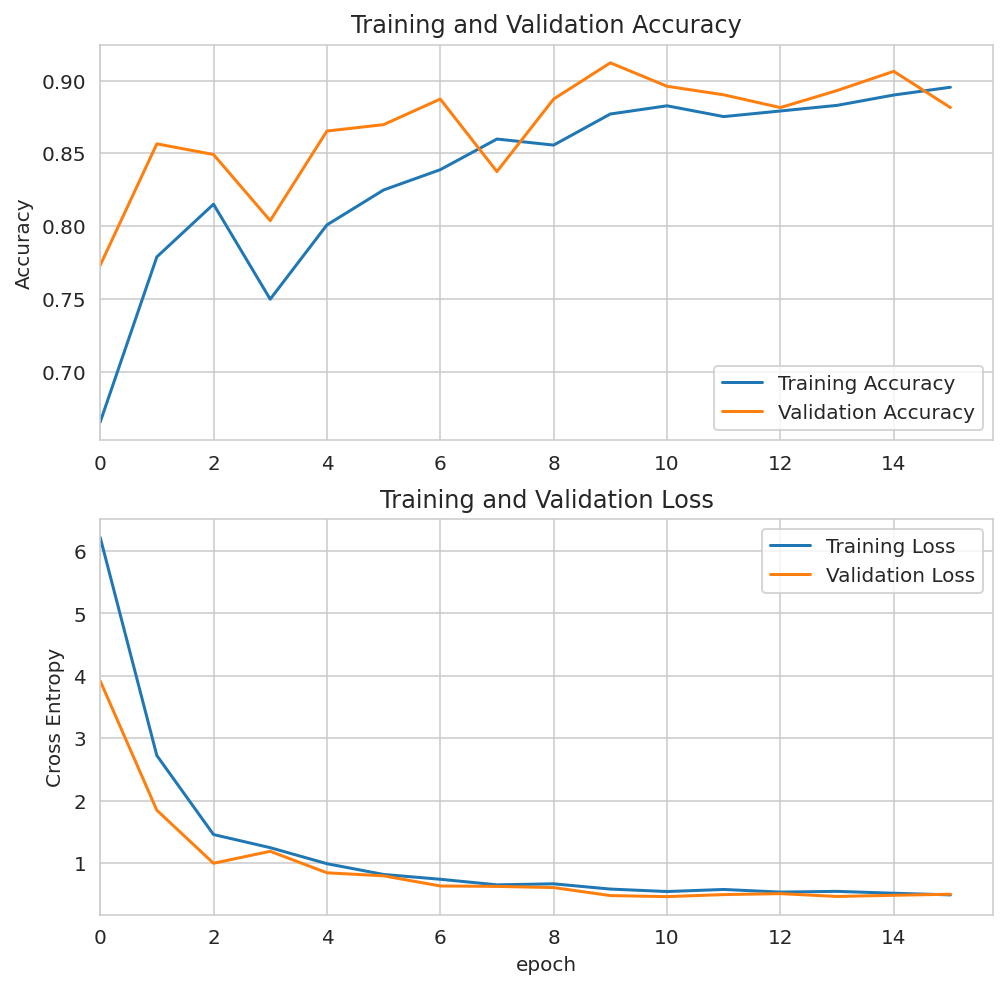

In [ ]:
learning_curves(acc,val_acc,loss,val_loss)

In [ ]:
# check for generalisation using epoch 11
metrics(epoch_num=10)

AUC percentage difference is: 0.8562820267706026 %

Accuracy percentage difference is: 1.5198837717666256 %


Initially, I did model running without allocating a test dataset. I just had training and validation datasets. With that arrangement, I managed to achieve good results with EfficientNet model (data augmentation layers included, Adam optimizer).

However, after allocating a test dataset, my model does not seem to learn as well, has a lower best accuracy and f1_score. 

In fact, it seems that adding data augmentation layers did not seem to improve model performance significantly.

Let's try base model with SGD Optimizer to see if accuracy can be improved further.

## Try with SGD Optimiser, to see if can improve accuracy score further
using base model

In [ ]:
# instantiate augmented model
model = E_Net()
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 rescaling_4 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 batch_normalization_3 (Batc  (None, 1536)             6144      
 hNormalization)                                                 
                                                                 
 dense_6 (Dense)             (None, 256)               393472    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0   

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.005, momentum=0.9), 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC', get_f1])

# Train the model, doing validation at the end of each epoch.
epochs = 50

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/ENet_sgd_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=5,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/ENet_history_sgd.csv') # save history
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/50
106/106 [==============================] - 280s 2s/step - loss: 6.6120 - accuracy: 0.9686 - auc: 0.9981 - get_f1: 0.9597 - val_loss: 5.6907 - val_accuracy: 0.9048 - val_auc: 0.9813 - val_get_f1: 0.9064
Epoch 2/50
106/106 [==============================] - 252s 2s/step - loss: 4.5984 - accuracy: 0.9950 - auc: 0.9998 - get_f1: 0.9951 - val_loss: 4.0657 - val_accuracy: 0.9195 - val_auc: 0.9823 - val_get_f1: 0.9110
Epoch 3/50
106/106 [==============================] - 276s 3s/step - loss: 3.2758 - accuracy: 0.9961 - auc: 0.9998 - get_f1: 0.9966 - val_loss: 2.9892 - val_accuracy: 0.9136 - val_auc: 0.9778 - val_get_f1: 0.9116
Epoch 4/50
106/106 [==============================] - 256s 2s/step - loss: 2.3433 - accuracy: 0.9982 - auc: 0.9999 - get_f1: 0.9975 - val_loss: 2.1770 - val_accuracy: 0.9283 - val_auc: 0.9857 - val_get_f1: 0.9294
Epoch 5/50
106/106 [==============================] - 264s 2s/step - loss: 1.6891 - accuracy: 0.9979 - auc: 1.0000 - get_f1: 0.9975 - val_loss: 1.66

Model with SGD optimizer tends to become overfitted easily.

## Learning Curves 

In [ ]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/ENet_history_sgd.csv')
history.head(3)

,epoch,accuracy,auc,get_f1,loss,val_accuracy,val_auc,val_get_f1,val_loss
0,0,0.968583,0.998098,0.959748,6.612018,0.904832,0.981315,0.906374,5.690721
1,1,0.994961,0.999844,0.995110,4.598384,0.919473,0.982264,0.910995,4.065696
2,2,0.996147,0.999825,0.996560,3.275838,0.913616,0.977837,0.911626,2.989166


In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

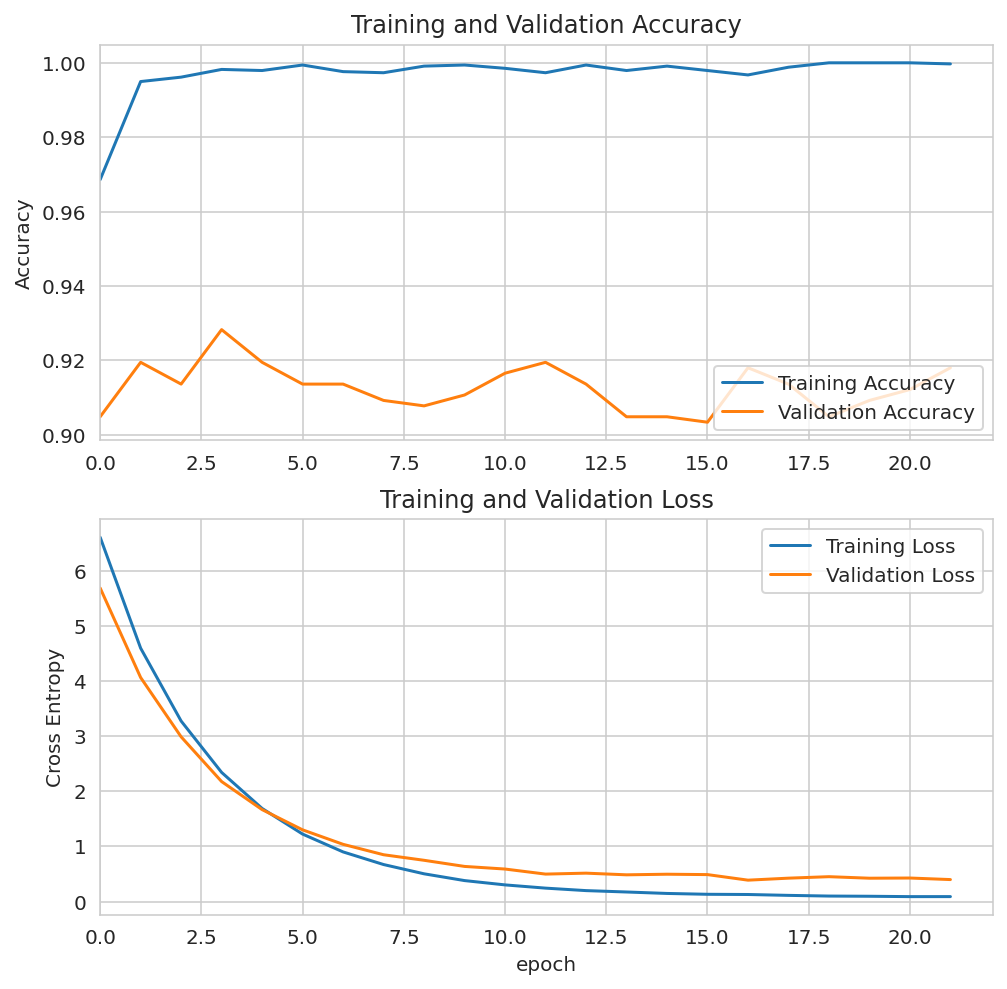

In [ ]:
learning_curves(acc,val_acc,loss,val_loss)

Even though model with SGD optimizer have generally better validation metrics compared to the base and augmented models, however the model is overfitted. 
So I have to consider between the base model and augmented models. The base model has a slightly better overall validation metric compared to model with data augmentation layer. Therefore, I will be using base model for further evaluation.

## Evaluation

using test dataset

__References:__
1. [images](https://machinelearningmastery.com/image-augmentation-with-keras-preprocessing-layers-and-tf-image/)
1. [kaggle code](https://www.kaggle.com/code/gpiosenka/eye-disease-f1-score-92-6/notebook)

In [146]:
# choose model for evaluation
# load model
model = tf.keras.models.load_model("drive/MyDrive/Colab Notebooks/ENet_ep9_val0.449", 
                                   custom_objects={'get_f1': get_f1})

### Confusion matrix

In [190]:
# for predictions
# class_names = train_ds.class_names # from previous cell
print(class_names)

preds = model.predict(test_ds, verbose=1)
print(preds[:5])
for array in preds:
  print(f'{class_names[0]} probability is: {array[0]:.4f}')
  print(f'{class_names[1]} probability is: {array[1]:.4f}')
  print(f'{class_names[2]} probability is: {array[2]:.4f}')
  print(f'{class_names[3]} probability is: {array[3]:.4f}')
  break

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
14/14 [==============================] - 7s 293ms/step
[[6.2647765e-04 9.9767405e-01 9.3619752e-04 7.6317217e-04]
 [9.8263139e-01 1.7959484e-03 4.5920098e-03 1.0980690e-02]
 [1.6602295e-02 4.5186281e-03 2.4163108e-01 7.3724806e-01]
 [7.2853465e-04 9.9818244e-05 9.9510682e-01 4.0648743e-03]
 [7.7374774e-04 9.9698812e-01 1.2748309e-03 9.6338050e-04]]
cataract probability is: 0.0006
diabetic_retinopathy probability is: 0.9977
glaucoma probability is: 0.0009
normal probability is: 0.0008


In [191]:
y_true = [] 
y_pred = []
image_list = []
for images, true_labels in test_ds.take(-1): # to iterate through all batches in test_ds
  # for y_true
  y_true.append(true_labels)
  image_list.append(images)
  # for y_pred
  preds = model.predict(images)
  idx = np.argmax(preds, axis=-1)
  preds = np.zeros( preds.shape ) # convert probabilities into OHE
  preds[ np.arange(preds.shape[0]), idx] = 1  
  y_pred.append(preds)
  
# because end result are nested arrays representing each batch (5), 
# to make it a continuous array, use np.concatenate
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# print('True labels:', true_labels.argmax(axis=1)[:5])
print('True labels:', true_labels[:5])
print('Predicted labels:', preds[:5])

True labels: tf.Tensor(
[[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]], shape=(5, 4), dtype=float32)
Predicted labels: [[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]]


[Multiclass confusion matrix](https://www.analyticsvidhya.com/blog/2021/06/confusion-matrix-for-multi-class-classification/#:~:text=Confusion%20Matrix%20is%20used%20to,number%20of%20classes%20or%20outputs.)


In [192]:
# confusion matrix using seaborn heatmap
from sklearn.metrics import confusion_matrix
# Creating  a confusion matrix,which compares the y_test and y_pred
cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))

# Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
cm_df = pd.DataFrame(cm,
                     index = class_names, 
                     columns = class_names)

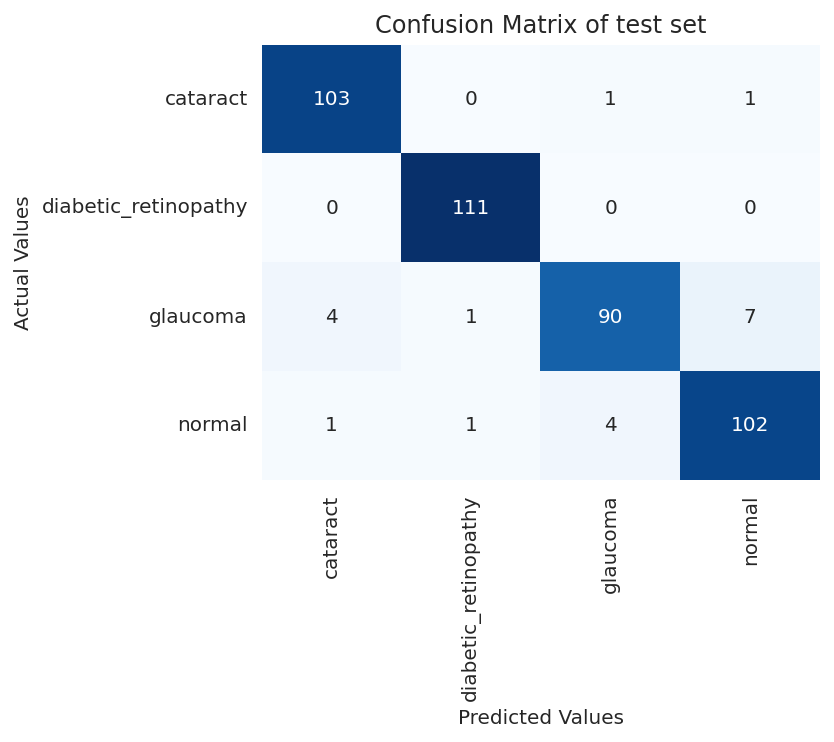

In [195]:
#Plotting confusion matrix using heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cbar=False, cmap='Blues', vmin=0, fmt='.3g', annot_kws={"size": 10})
plt.title('Confusion Matrix of test set')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

### Classification report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names, digits= 4))

                      precision    recall  f1-score   support

            cataract     0.8936    0.8750    0.8842        48
diabetic_retinopathy     0.9474    1.0000    0.9730        36
            glaucoma     0.7931    0.8214    0.8070        28
              normal     0.9130    0.8750    0.8936        48

           micro avg     0.8938    0.8938    0.8938       160
           macro avg     0.8868    0.8929    0.8895       160
        weighted avg     0.8939    0.8938    0.8935       160
         samples avg     0.8938    0.8938    0.8938       160



Model is not great at identifying glaucoma compared to other conditions, which makes sense due to the lowest support in the dataset. The model is best at identifying diabetic retinopathy.

## Misclassified test images

In [ ]:
image_list = np.concatenate(image_list) # numpy array representation of images

In [199]:
# extract test file names from test_ds
test_filenames = test_ds.file_paths

['./work_directory/test/diabetic_retinopathy/11232_right.jpeg', './work_directory/test/cataract/_4_7491150.jpg', './work_directory/test/diabetic_retinopathy/10305_right.jpeg']


In [198]:
len(test_filenames)

426

In [200]:
# convert OHE to class_names for easier comparison 
y_true_labels = tf.argmax(y_true, axis=1).numpy() # tensor object not iterable, use numpy to convert to list
y_pred_labels = tf.argmax(y_pred, axis=1).numpy()

error_list = []

for a, b, c in zip(y_true_labels, y_pred_labels, test_filenames):
  if a != b:
    error_list.append((a,b,c))

In [201]:
len(error_list)

20

In [205]:
error_list # check for duplicates

[(0, 2, './work_directory/test/normal/2858_left.jpg'),
 (2, 3, './work_directory/test/normal/2812_right.jpg'),
 (3, 2, './work_directory/test/glaucoma/1286_right.jpg'),
 (2, 1, './work_directory/test/cataract/_21_4533748.jpg'),
 (2, 3, './work_directory/test/normal/2540_left.jpg'),
 (3, 1, './work_directory/test/normal/2465_right.jpg'),
 (2, 3, './work_directory/test/cataract/cataract_062.png'),
 (2, 0, './work_directory/test/normal/2345_left.jpg'),
 (3, 0, './work_directory/test/diabetic_retinopathy/11392_left.jpeg'),
 (3, 2, './work_directory/test/diabetic_retinopathy/11037_right.jpeg'),
 (3, 2, './work_directory/test/cataract/cataract_073.png'),
 (2, 3, './work_directory/test/normal/2713_left.jpg'),
 (0, 3, './work_directory/test/cataract/_134_4903477.jpg'),
 (2, 3, './work_directory/test/diabetic_retinopathy/11371_left.jpeg'),
 (2, 3, './work_directory/test/glaucoma/1495_left.jpg'),
 (2, 0, './work_directory/test/normal/2755_left.jpg'),
 (2, 3, './work_directory/test/cataract/catar

In [206]:
error_list[1][2]

'./work_directory/test/normal/2812_right.jpg'

ValueError: ignored

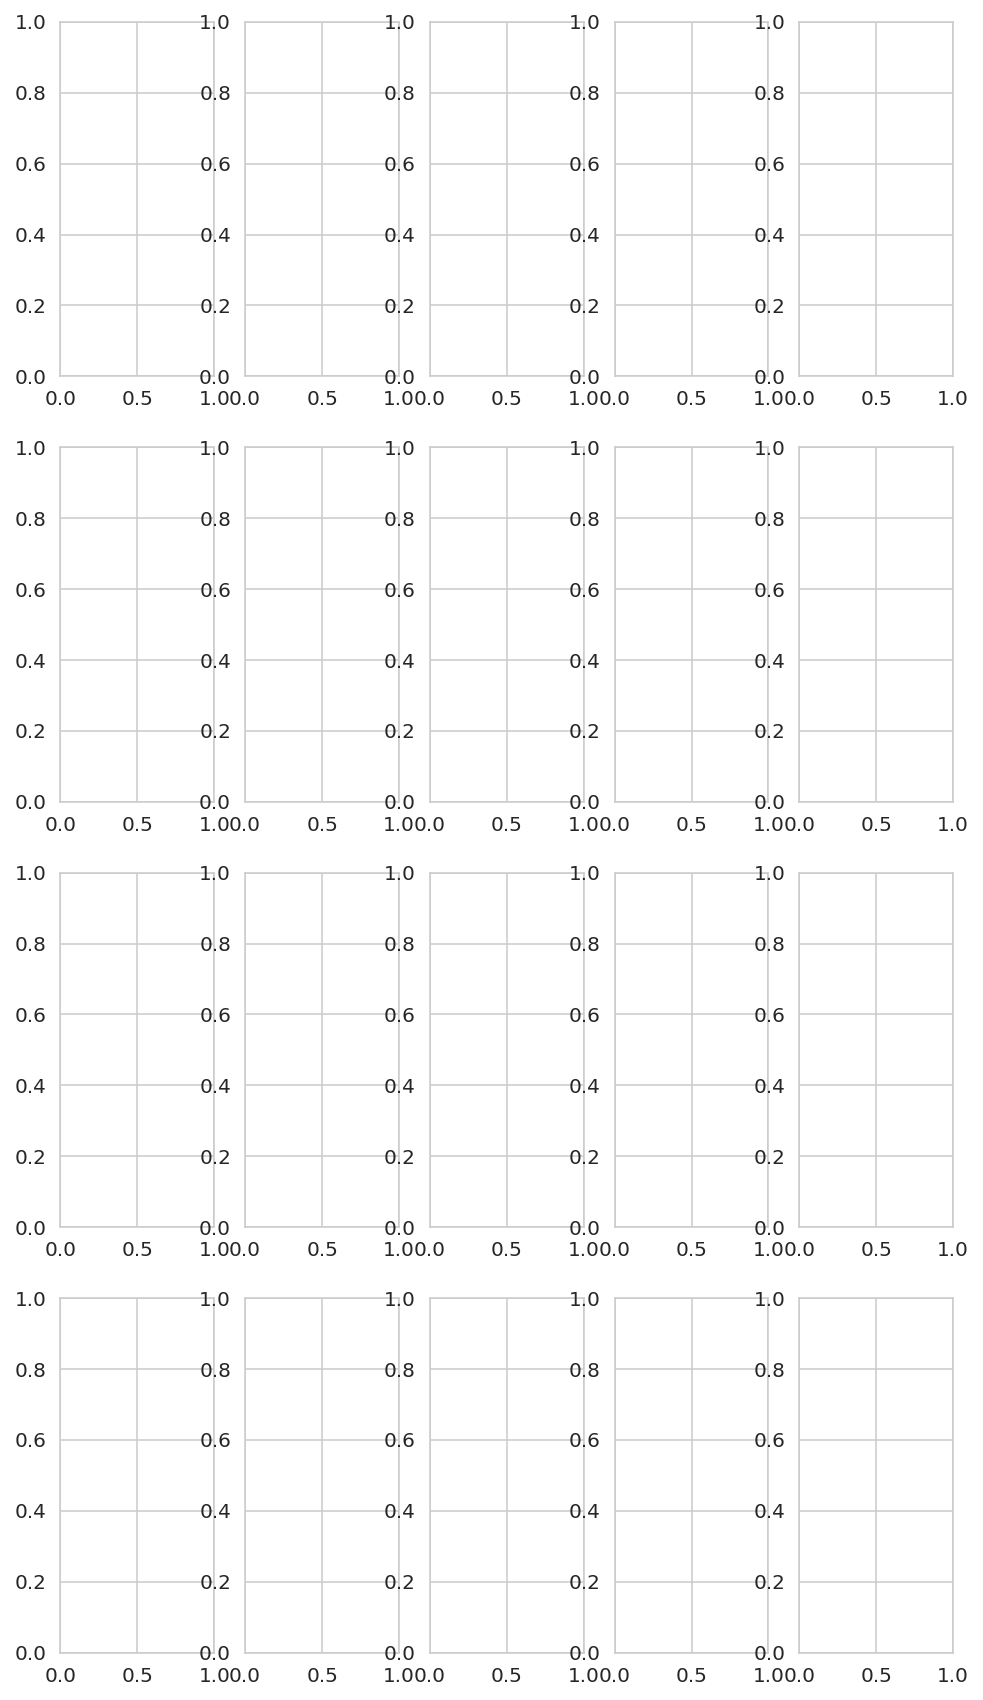

In [210]:
from PIL import Image

fig, axes = plt.subplots(4, 5, figsize=(8, 15))

for true_label, pred_label, f_path, ax in zip(error_list, axes.ravel()): 
  img = Image.open(f_path)
  ax.imshow(img)
    
  #plt.imshow(image.astype('uint8'))
  #for i in range(10):
    #ax[i].imshow(image.astype('uint8'))

    # image_tensor = tf.convert_to_tensor(image)
    
    #plt.title(class_names[true_label[i]])
    #plt.subtitle(class_names[pred_label[i]])
    #plt.axis("off")
'''
for images, labels in train_ds.take(1): # each image 160 x 160
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[i], axis=0)])
    plt.axis("off")
'''

In [ ]:
# compare images with true vs predicted labels

In [ ]:
for images, labels in train_ds.take(1): # each image 160 x 160
 # print(images[i])
  print(images[i].numpy())
  break

[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]
(160, 160, 3)


### ROC curve only if comparing with another model

In [ ]:
# ROC curve

In [ ]:
# PR curve